# Principal Axes Transformation (PAT)

In [41]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../code')

import numpy as np
import matplotlib.pyplot as plt
import registration as reg
import registration_util as util

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---
## Section 1 — Load images

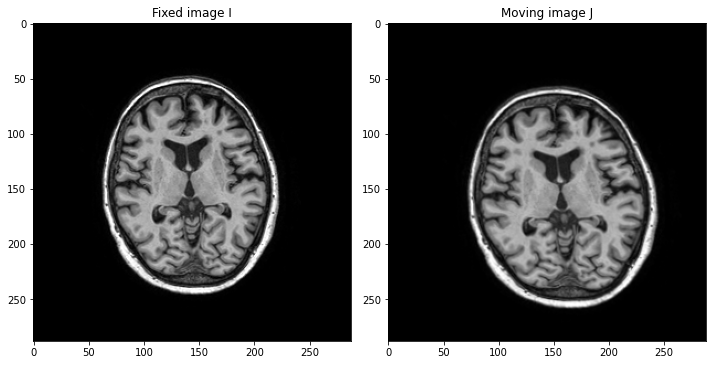

In [42]:
I  = plt.imread('../data/image_data/3_2_t1.tif')    # fixed image
J  = plt.imread('../data/image_data/3_2_t1_d.tif')  # moving image

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(I, cmap='gray')
axes[0].set_title('Fixed image I')
axes[1].imshow(J, cmap='gray')
axes[1].set_title('Moving image J')
plt.tight_layout()
plt.show()

---
## Section 2 — Principal Axes Transformation

PAT aligns two images by computing the intensity-weighted **centre of mass** and the **inertia matrix** for each image, then finding the rotation that maps one set of principal axes onto the other.

### Function 1 — Centre of mass

Pixel intensities are treated as mass weights. The intensity-weighted mean position is:

$$c_x = \frac{\sum_{r,c} I(r,c)\cdot c}{\sum_{r,c} I(r,c)}, \qquad c_y = \frac{\sum_{r,c} I(r,c)\cdot r}{\sum_{r,c} I(r,c)}$$

where $c$ is the **column** index (the $x$ coordinate) and $r$ is the **row** index (the $y$ coordinate).

In [43]:
def compute_centre_of_mass(I):
    """
    Compute the intensity-weighted centre of mass of a 2D image.

    Returns
    -------
    com : ndarray, shape (2,)
        [cx, cy] where cx is the weighted mean column index
        and cy is the weighted mean row index.
    """
    rows, cols = np.indices(I.shape)   # rows[r,c]=r,  cols[r,c]=c
    total = I.sum()
    cx = (I * cols).sum() / total
    cy = (I * rows).sum() / total
    return np.array([cx, cy])

### Function 2 — Inertia matrix

The **2×2 inertia matrix** encodes how the image mass is distributed around the centre of mass:

$$\mu_{20} = \frac{\sum I(r,c)(c-c_x)^2}{\sum I}, \quad
  \mu_{02} = \frac{\sum I(r,c)(r-c_y)^2}{\sum I}, \quad
  \mu_{11} = \frac{\sum I(r,c)(c-c_x)(r-c_y)}{\sum I}$$

$$M = \begin{pmatrix} \mu_{20} & \mu_{11} \\ \mu_{11} & \mu_{02} \end{pmatrix}$$

In [44]:
def compute_second_moment_matrix(I, com):
    """
    Compute the 2x2 intensity-weighted second moment (inertia) matrix.

    Parameters
    ----------
    I   : 2D ndarray — image
    com : ndarray shape (2,) — [cx, cy] from compute_centre_of_mass

    Returns
    -------
    M : ndarray, shape (2, 2)
    """
    cx, cy = com
    rows, cols = np.indices(I.shape)
    total = I.sum()

    dx = cols - cx   # column displacement  (x direction)
    dy = rows - cy   # row displacement     (y direction)

    mu20 = (I * dx**2).sum() / total
    mu02 = (I * dy**2).sum() / total
    mu11 = (I * dx * dy).sum() / total

    return np.array([[mu20, mu11],
                     [mu11, mu02]])

### Function 3 — Principal axes

The **principal axes** are the eigenvectors of the inertia matrix $M$.  The eigenvector corresponding to the **largest** eigenvalue points along the direction of greatest mass spread (the major axis).

In [45]:
def compute_principal_axes(M):
    """
    Compute principal axes from a 2x2 second moment matrix.

    Returns
    -------
    S : ndarray, shape (2, 2)
        Columns are eigenvectors sorted by descending eigenvalue.
        S[:, 0] is the major (principal) axis.
    """
    eigenvalues, eigenvectors = np.linalg.eigh(M)
    # eigh returns ascending order — reverse to get descending
    idx = np.argsort(eigenvalues)[::-1]
    return eigenvectors[:, idx]

### Function 4 — Principal Axes Transform

Given the principal axes matrices $S_I$ (fixed) and $S_J$ (moving), the rotation that maps the moving axes onto the fixed axes is:

$$R = S_I \, S_J^\top$$

The corresponding translation centres both images after rotation:

$$\mathbf{t} = \mathbf{c}_I - R\,\mathbf{c}_J$$

This defines a **forward** mapping $\mathbf{x}_I = R\,\mathbf{x}_J + \mathbf{t}$.

`image_transform` uses **inverse mapping**: for each output pixel $\mathbf{p}$ (in the fixed frame) it looks up the source pixel via $T_h\,\mathbf{p}$ (in the moving frame). Therefore the matrix passed to `image_transform` must be the **inverse** of the forward transform:

$$T_h = \begin{pmatrix} R^\top & \mathbf{c}_J - R^\top\mathbf{c}_I \\ \mathbf{0}^\top & 1 \end{pmatrix}$$

Because eigenvectors are defined up to a sign, a 180° ambiguity exists. Both $S$ and $-S$ are valid; we resolve it by trying both orientations and keeping the one with higher NCC.

In [46]:
def principal_axes_transform(I, J):
    """
    Compute the PAT homogeneous matrix that registers moving image J to fixed image I.

    Returns
    -------
    Th_best : ndarray, shape (3, 3)
        Homogeneous transformation matrix for use with image_transform.
        Maps fixed-image coordinates to moving-image coordinates (inverse mapping).
    """
    # -- centres of mass --
    com_I = compute_centre_of_mass(I)
    com_J = compute_centre_of_mass(J)

    # -- second moment matrices --
    M_I = compute_second_moment_matrix(I, com_I)
    M_J = compute_second_moment_matrix(J, com_J)

    # -- principal axes --
    S_I = compute_principal_axes(M_I)
    S_J = compute_principal_axes(M_J)

    # -- rotation that maps J's axes onto I's axes --
    R = S_I @ S_J.T

    # report rotation angle
    theta = np.arctan2(R[1, 0], R[0, 0])
    print(f'Rotation angle: {theta:.4f} rad  ({np.degrees(theta):.2f} deg)')

    def build_Th(R_mat):
        # inverse mapping: fixed -> moving
        R_inv = R_mat.T
        t_inv = com_J - R_inv @ com_I
        return util.t2h(R_inv, t_inv)

    Th      = build_Th(R)
    Th_flip = build_Th(-R)   # 180-degree flipped solution

    J_t,      _ = reg.image_transform(J, Th)
    J_t_flip, _ = reg.image_transform(J, Th_flip)

    ncc      = reg.correlation(I, J_t)
    ncc_flip = reg.correlation(I, J_t_flip)

    if ncc >= ncc_flip:
        print(f'Selected: original orientation  (NCC={ncc:.4f} vs flipped NCC={ncc_flip:.4f})')
        return Th
    else:
        theta_flip = np.arctan2(-R[1, 0], -R[0, 0])
        print(f'Selected: flipped orientation   (NCC={ncc_flip:.4f} vs original NCC={ncc:.4f})')
        print(f'Adjusted rotation angle: {theta_flip:.4f} rad  ({np.degrees(theta_flip):.2f} deg)')
        return Th_flip

---
## Section 3 — Apply the transformation

We call `principal_axes_transform` to obtain the homogeneous matrix `Th_pat`, apply it with `image_transform` to produce the registered image, then display the three images and the difference images for visual inspection.

In [47]:
Th_pat = principal_axes_transform(I, J)
J_registered, _ = reg.image_transform(J, Th_pat)

Rotation angle: 0.1535 rad  (8.79 deg)
Selected: original orientation  (NCC=0.7328 vs flipped NCC=0.6752)


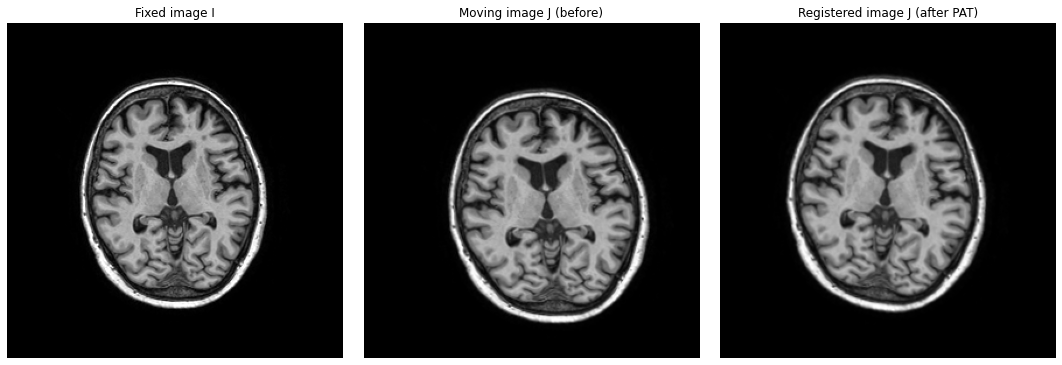

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(I, cmap='gray')
axes[0].set_title('Fixed image I')

axes[1].imshow(J, cmap='gray')
axes[1].set_title('Moving image J (before)')

axes[2].imshow(J_registered, cmap='gray')
axes[2].set_title('Registered image J (after PAT)')

for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

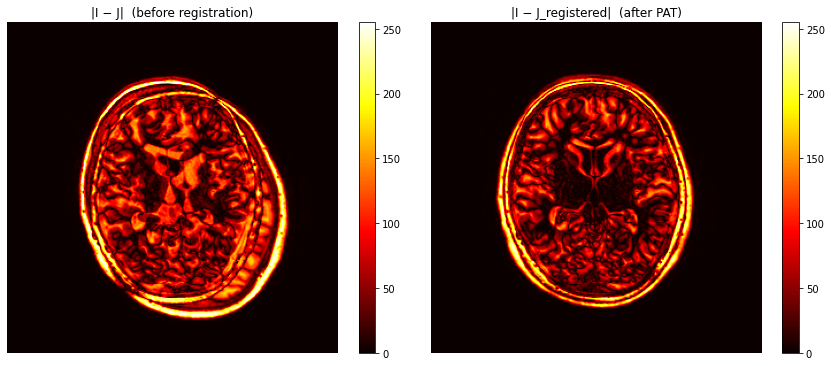

In [49]:
I_float        = I.astype(float)
J_float        = J.astype(float)
J_reg_float    = J_registered.astype(float)

diff_before = np.abs(I_float - J_float)
diff_after  = np.abs(I_float - J_reg_float)

vmax = max(diff_before.max(), diff_after.max())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(diff_before, cmap='hot', vmin=0, vmax=vmax)
axes[0].set_title('|I − J|  (before registration)')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(diff_after, cmap='hot', vmin=0, vmax=vmax)
axes[1].set_title('|I − J_registered|  (after PAT)')
plt.colorbar(im1, ax=axes[1])

for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

---
## Section 4 — Evaluate the registration

We quantify registration quality using two similarity metrics:

| Metric | Direction |
|--------|-----------|
| **Normalised Cross-Correlation (NCC)** | Higher is better (max = 1) |
| **Mutual Information (MI)**            | Higher is better |

Both are computed before and after PAT using the existing functions from `registration.py`.

In [50]:
# NCC
ncc_before = reg.correlation(I, J)
ncc_after  = reg.correlation(I, J_registered)

# MI
mi_before = reg.mutual_information(reg.joint_histogram(I, J))
mi_after  = reg.mutual_information(reg.joint_histogram(I, J_registered))

print('=' * 46)
print(f'{"Metric":<30} {"Before":>7}  {"After":>7}')
print('-' * 46)
print(f'{"NCC":<30} {ncc_before:>7.4f}  {ncc_after:>7.4f}')
print(f'{"Mutual Information (nats)":<30} {mi_before:>7.4f}  {mi_after:>7.4f}')
print('=' * 46)

Metric                          Before    After
----------------------------------------------
NCC                             0.5994   0.7328
Mutual Information (nats)       0.3749   0.5588


### Interpretation

**Did PAT recover the correct transformation?**

PAT is an **initialisation** method — it uses global image statistics (centre of mass and inertia) rather than local intensity patterns, so it can only recover the dominant rotational offset between two images.  Its accuracy therefore depends on how well the intensity distribution approximates the object's geometric shape:

- If both NCC and MI **increase** after PAT, the method has succeeded in substantially reducing the misalignment, and the residual error can be removed by a subsequent intensity-based optimisation step.
- If the metrics do **not** improve (or improve only marginally), the underlying transformation likely contains components (e.g. large translations, scaling, or shear) that are not captured by principal axes alone.
- The 180° ambiguity check ensures we do not select the mirror-flipped solution, which is a common failure mode of eigendecomposition-based alignment.

Overall, PAT provides a **fast, parameter-free, landmark-free** coarse alignment that can significantly reduce the search space for iterative intensity-based registration optimisers.